# Machine Vision
## Assignment 8 - Deep Learning



## Introduction

This assignment focuses on the CLIP model, which stands for Contrastive Language Image Pretraining. CLIP has two parts: an image encoder that turns an image into a vector, and a text encoder that turns a text description into a vector (see the figure below). Both vectors $I_i$ and $T_i$ live in the same embedding space, so we can compare them directly. For example, the text query “a dog lying on grass” should be more similar to an image of a dog than to an image of a car. CLIP was trained on a large collection of image–text pairs so that matching pairs end up close to each other in this space, while unrelated pairs end up farther apart.

<img src="attachment:37795e2d-6c02-49a5-a5f9-c12ca55d18e4.png" width="600">

In Task 1, you will visualize the provided image embeddings in 2D using PCA (Principal Component Analysis) and inspect whether images from the same class form clusters. In Task 2, you will implement a small text-based image retrieval system that returns the most relevant images for a given text query embedding. For convenience, you do not need to install or run CLIP yourself because all embeddings are provided. If you are interested in running CLIP yourself, you can find more information from __[here](https://github.com/openai/CLIP)__.

**Note!** The package *scikit-learn* is needed. If you encounter problems, install it by running `pip install -U scikit-learn` in the terminal (please do not add installation commands to the notebook).

Let us first load the embeddings and print their dimensions.

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Load image embeddings
img_data = np.load("image_embeddings.npz", allow_pickle=True)
filenames = img_data["filenames"].astype(str)
labels = img_data["labels"].astype(str)
embs_img = img_data["embeddings"].astype(np.float32)

print(f"Number of image embeddings: {embs_img.shape[0]}")
print(f"Image embedding dimension: {embs_img.shape[1]}")

# Load text embeddings
txt_data = np.load("text_embeddings.npz", allow_pickle=True)
queries = txt_data["queries"].astype(str)
embs_txt = txt_data["embeddings"].astype(np.float32)

print(f"Number of text embeddings: {embs_txt.shape[0]}")
print(f"Text embedding dimension: {embs_txt.shape[1]}")

print("\nQuery texts:")
for i, q in enumerate(queries):
    print(f"[{i}] {q}")

Number of image embeddings: 60
Image embedding dimension: 512
Number of text embeddings: 4
Text embedding dimension: 512

Query texts:
[0] a dog lying on grass
[1] red tulips
[2] not so nice looking car
[3] a sleepy cat


The following code displays the 10th image embedding and its corresponding image. There are 60 images in total, each belonging to one of the four classes (*car, cat, dog, flower*).

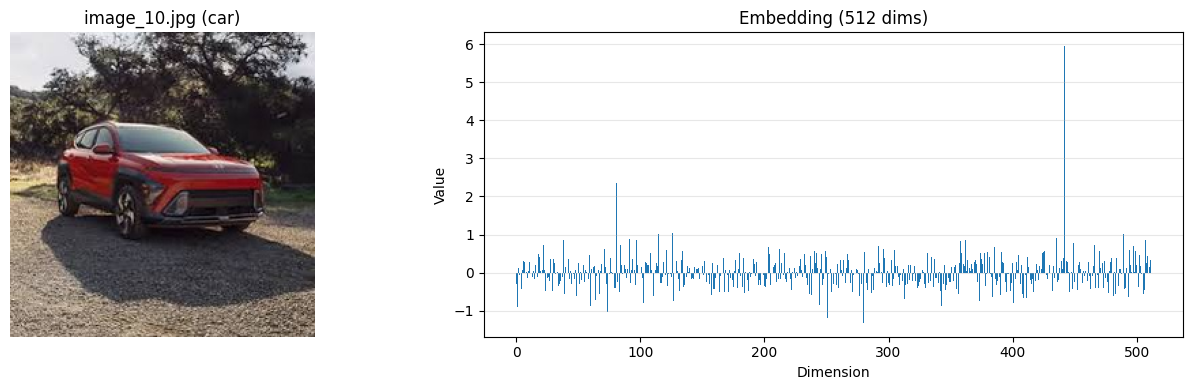

In [3]:
idx = 9  # 10th element

img_bgr = cv2.imread(f"images/{filenames[idx]}", cv2.IMREAD_COLOR)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
emb_img = embs_img[idx]

plt.figure(figsize=(14, 4))

# Left: image
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title(f"{filenames[idx]} ({labels[idx]})")
plt.axis("off")

# Right: embedding
plt.subplot(1, 2, 2)
plt.bar(np.arange(emb_img.shape[0]), emb_img)
plt.title(f"Embedding ({emb_img.shape[0]} dims)")
plt.xlabel("Dimension")
plt.ylabel("Value")
plt.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Task 1 - PCA visualization <span style="color: red;">(1.0 point)</span>

In this task you will visualize the image embeddings in 2D using PCA (Principal Component Analysis). PCA finds a 2D subspace that preserves as much variance of the original embeddings as possible. You will fit PCA using the image embeddings, then project all image embeddings into 2D. In addition, you will also project the first text embedding (query text: *"a dog lying on grass"*) into the same 2D space. The aim is to create a scatter plot where different image classes use different colors, and the text embedding is shown using a different marker. The visualization should look similar to the following example. However, your plot may look mirrored compared to the example due to PCA sign ambiguity.

<img src="attachment:fff778ec-f96d-4864-afac-e19b054756f7.png" width="600">

You can see that images from the same class tend to form clusters in the 2D PCA space. The dog and cat clusters are partially overlapping, which makes sense because these classes share many visual patterns and CLIP often places semantically similar categories relatively close in the embedding space. Note also that the text embedding (black marker) is surprisingly far from the dog cluster in the 2D plot. A key reason is that PCA shows only a 2D projection of a 512D space, so the 2D distances may not accurately reflect the true similarities between embeddings.

**Instructions**
- See the scikit-learn documentation for __[PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)__, including the examples.
- Fit a PCA model with `n_components=2` using the image embeddings and the __[fit()](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html#sklearn.decomposition.PCA.fit)__ method.
- Use the __[transform()](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html#sklearn.decomposition.PCA.transform)__ method to project image embeddings `embs_img` and the first text embedding `embs_txt[0]` to 2D using the same PCA model.
- Plot the projected image embeddings as a scatter plot, using different colors for different classes.
- Plot the projected first text embedding using a different marker than the images.
- You can freely choose the colors and markers.

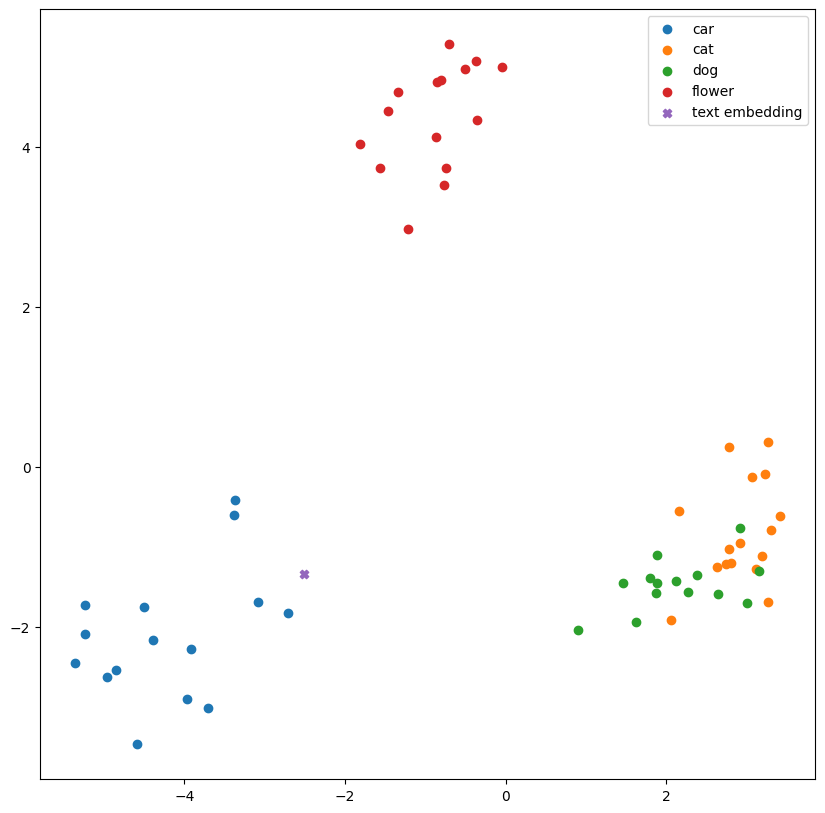

In [4]:
from sklearn.decomposition import PCA

# ---------- YOUR CODE STARTS HERE -----------

# 1. Fit PCA on image embeddings
pca = PCA(n_components=2)
pca.fit(embs_img)

# 2. Project image embeddings and the first text embedding
emb_2d = pca.transform(embs_img)
emb_txt_2d = pca.transform(embs_txt[0].reshape(1, -1))


# 3. Plot
plt.figure(figsize=(10, 10))
classes = np.unique(labels)

for cls in classes:
    idx=labels==cls
    plt.scatter(
        emb_2d[idx,0],
        emb_2d[idx,1],
        label=f"{cls}",
    )

plt.scatter(
    emb_txt_2d[0,0],
    emb_txt_2d[0,1],
    marker="X",
    label="text embedding"
)
plt.legend()
plt.show()
# ----------- YOUR CODE ENDS HERE ------------

## Task 2 - Image retrieval <span style="color: red;">(1.0 point)</span>

In this task you will implement a simple text-based image retrieval system using the CLIP embeddings. Given a text embedding vector $\mathbf{t}$ and an image embedding vector $\mathbf{v}$, we measure their similarity using cosine similarity:
$$
S_\mathrm{cos}(\mathbf{t}, \mathbf{v}) = \frac{\mathbf{t}^\top \mathbf{v}}{\|\mathbf{t}\|_2 \, \|\mathbf{v}\|_2}
$$
Here $\mathbf{t}$ and $\mathbf{v}$ refer to the original CLIP embeddings (512-dimensional vectors), not the 2D PCA projections from Task 1.

You will compute cosine similarity between one text embedding and all image embeddings, then return the indices of the top matches. For example, if we use the first text embedding that corresponds to the query *"a dog lying on grass"*, we should find the following images. All retrieved images include dogs, and the first retrieved image matches the prompt most closely and therefore has the highest similarity score.

<img src="attachment:03f3bff4-ec4a-4e8d-90a4-6833dd343d66.jpg" width="800">

**Instructions**
- Implement the cosine similarity equation in the function **retrive_images()**.
- Compute similarities between the selected text embedding `emb_txt` and all image embeddings `embs_img`.
- The function should return the indices of the `top_k` most similar images (highest similarity first) and the corresponding similarity values.
- Use the provided visualization cell to inspect the results.

In [5]:
def retrieve_images(embs_img, emb_txt, top_k=3):
    """
    Inputs:
        embs_img: (N, D) image embeddings
        emb_txt:  (D,) one text embedding
        top_k:    number of returned images

    Outputs:
        top_idx:  (top_k,) indices of best matches (descending similarity)
        top_sims: (top_k,) cosine similarity values for those indices
    """

    # ---------- YOUR CODE STARTS HERE -----------
    similarity=[]
    for img in embs_img:
      S_cos=np.dot(emb_txt,img)/(np.linalg.norm(emb_txt)*np.linalg.norm(img))
      similarity.append(S_cos)

    similarity=np.array(similarity)
    top_idx=np.argsort(similarity)[-top_k:][::-1]
    top_sims=similarity[top_idx]

    # ----------- YOUR CODE ENDS HERE ------------

    return top_idx, top_sims



The following code calls your function to retrieve the top 3 most similar images for a given text prompt. The retrieved images and similarity scores should match those shown earlier. You can also try the other text prompts by changing the `query_idx` parameter (0 to 3).

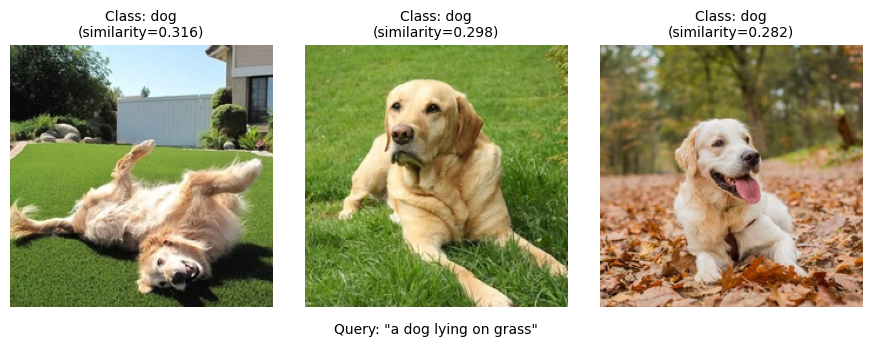

In [6]:
# Visualize retrieval results for one query

query_idx = 0
top_k = 3
top_idx, top_sims = retrieve_images(embs_img, embs_txt[query_idx], top_k=top_k)

fig = plt.figure(figsize=(3 * top_k, 3.5))

for j, (idx, sim) in enumerate(zip(top_idx, top_sims)):
    img_bgr = cv2.imread(f"images/{filenames[idx]}", cv2.IMREAD_COLOR)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    plt.subplot(1, top_k, j + 1)
    plt.imshow(img_rgb)
    plt.title(f"Class: {labels[idx]}\n(similarity={sim:.3f})", fontsize=10)
    plt.axis("off")

fig.subplots_adjust(bottom=0.22)
fig.text(0.5, 0.08, f'Query: "{queries[query_idx]}"', ha="center", va="center", fontsize=10)
plt.tight_layout(rect=[0, 0.10, 1, 1])
plt.show()